In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from transformer_lens import HookedTransformer
from tqdm import tqdm

import src.data.opi as opi
import src.utils.utils as utils

In [6]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TASK_TYPE = "sentiment"
INJECTED_TASK = "spam"

In [5]:
model = HookedTransformer.from_pretrained(MODEL_NAME, device=DEVICE)
tokenizer = model.tokenizer

prompts = opi.load_opi(model=model, task_type=TASK_TYPE, injected_task=INJECTED_TASK, include_clean=True)
safe, naive, escape, ignore, combine = prompts.values()

: 

In [ ]:
n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads
layers = [f"blocks.{i}.attn.hook_pattern" for i in range(n_layers)]

In [ ]:
def make_metric(clean_logits, corrupted_logits):
    clean_last      = clean_logits[0, -1, :]
    corrupted_last  = corrupted_logits[0, -1, :]
    baseline_dist   = (clean_last - corrupted_last).abs().mean()

    def metric(logits):
        patched_last = logits[0, -1, :]
        patched_dist = (clean_last - patched_last).abs().mean()
        # Recovery: 1 = fully restored to clean, 0 = no change from corrupted
        return 1 - patched_dist / (baseline_dist + 1e-8)
    return metric


def make_hook_z_patch(layer, head, clean_cache):
    """
    Patches hook_z at the last token position for a specific head.
    clean_cache: ActivationCache with remove_batch_dim=True
    hook_z shape: [seq, n_heads, d_head]
    """
    def hook_fn(z, hook):
        # z shape: [batch, seq, n_heads, d_head]
        z[0, -1, head, :] = clean_cache[f"blocks.{layer}.attn.hook_z"][-1, head, :]
        return z
    return hook_fn


def patch_hook_z(model, clean_cache, corrupted_tokens, metric, heads):
    """
    Returns [n_layers, n_heads] recovery tensor using hook_z patching.
    """
    results = torch.zeros(model.cfg.n_layers, model.cfg.n_heads)
    for l, h in heads:
        hook = make_hook_z_patch(l, h, clean_cache)
        with model.hooks(fwd_hooks=[(f"blocks.{l}.attn.hook_z", hook)]):
            patched_logits = model(corrupted_tokens, return_type="logits")
        results[l, h] = metric(patched_logits).item()
    return results


def patching_z_experiment(results_dict, exp_name, clean, corrupted, N):
  hook_z_layers = [f"blocks.{i}.attn.hook_z" for i in range(n_layers)]

  results_dict[exp_name] = torch.zeros(n_layers, n_heads)

  for clean_prompt, corr_prompt in tqdm(zip(clean, corrupted), total=N):
    utils.clear_cuda_cache()

    clean_logits, clean_cache = model.run_with_cache(
        clean_prompt,
        names_filter=hook_z_layers,
        remove_batch_dim=True   # cache shape [seq, n_heads, d_head] — no batch dim
    )

    corrupted_logits = model(corr_prompt)
    recovery_metric = make_metric(clean_logits=clean_logits, corrupted_logits=corrupted_logits)

    corrupted_tokens = model.to_tokens(corr_prompt)
    heads = [(l, h) for l in range(n_layers) for h in range(n_heads)]

    patched_result = patch_hook_z(
        model=model,
        clean_cache=clean_cache,
        corrupted_tokens=corrupted_tokens,
        metric=recovery_metric,
        heads=heads
    )

    results_dict[exp_name] += patched_result.to("cpu")

In [30]:
RECOMPUTE = False

if RECOMPUTE==True:
    patching_results_z = {}

    patching_z_experiment(patching_results_z, "(safe, naive)", safe[:30], naive[:30], N=30)
    patching_z_experiment(patching_results_z, "(safe, combine)", safe[:30], combine[:30], N=30)
    patching_z_experiment(patching_results_z, "(naive, ignore)", naive[:30], ignore[:30], N=30)
    patching_z_experiment(patching_results_z, "(naive, combine)", naive[:30], combine[:30], N=30)
    patching_z_experiment(patching_results_z, "(ignore, combine)", ignore[:30], combine[:30], N=30)
    patching_z_experiment(patching_results_z, "(naive, escape)", naive[:30], escape[:30], N=30)

    torch.save(patching_results_z, f"results/patching_results_z_{INJECTED_TASK}.pt")

else:
    patching_results_z = torch.load("results/patching_results_z_spam.pt", map_location=DEVICE)

In [11]:
def plot_act_patching(values, name_clean, name_corrupted, N, verbose=False, savefig=False):
  """
  Plots the contribution of each head in the residual stream
  Arguments :
  - head_contribs : Tensor[(n_layers, n_heads)]
  """
  import matplotlib.colors as mcolors

  if values.is_cuda:
    tensor = values.detach().cpu()/N
  else:
    tensor = values/N

  vmax = np.abs(tensor).max()
  vmin = -vmax

  norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

  plt.pcolormesh(tensor, cmap="RdBu_r", norm=norm)
  plt.xlabel("Heads")
  plt.ylabel("Layers")
  plt.title(f"Activation patching from {name_clean} to {name_corrupted} (N={N})")

  if verbose:
    # Annotate each cell
    for i in range(tensor.shape[0]):
        for j in range(tensor.shape[1]):
          if abs(tensor[i, j]) > 0.5:
            plt.text(j + 0.5, i + 0.5, f"{tensor[i, j]:.2f}",
                    ha="center", va="center", color="black")

  plt.tight_layout(rect=[0, 0, 0.88, 1])  # reserve right margin for colorbar

  cbar_ax = plt.axes([0.90, 0.15, 0.02, 0.7])

  plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="RdBu_r"),
              cbar_ax,
              label="Mean effect of patching on ASR")

  plt.show()
  if savefig:
    plt.savefig(f"act_patching_{name_clean}_to_{name_corrupted}.png")


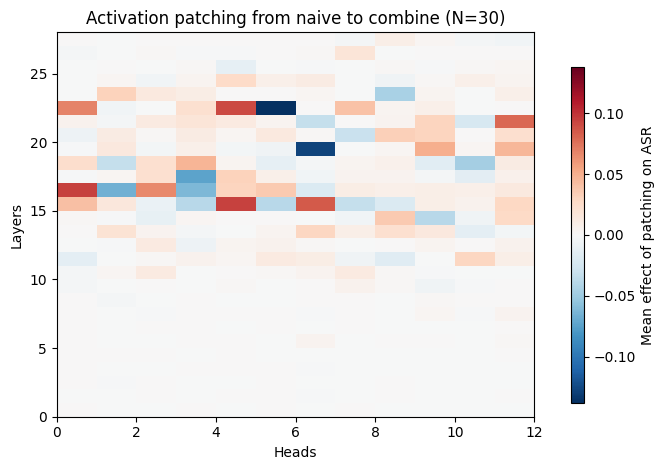

In [32]:
plot_act_patching(patching_results_z["(naive, combine)"], 
                                     name_clean="naive", 
                                     name_corrupted="combine",
                                     N=30)

In [27]:
def plot_all_patching(results_dict:dict, N):
    nrows, ncols = (len(results_dict)+1)//2, 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5*nrows))
    axes = axes.flatten()

    keys = patching_results_z.keys()
    tensors = patching_results_z.values()

    vmax = max(np.abs(t/N).max() for t in tensors)
    vmin = -vmax

    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    for ax, tensor, key in zip(axes, tensors, keys):
        im = ax.pcolormesh(tensor/N, cmap="RdBu_r", norm=norm)
        ax.set_title(key, fontsize=12)
        ax.set_xlabel("Heads")
        ax.set_ylabel("Layers")
        ax.set_xticks(np.arange(tensor.shape[1]) + 0.5)
        ax.set_xticklabels(np.arange(tensor.shape[1]))
        ax.set_yticks(np.arange(tensor.shape[0]) + 0.5)
        ax.set_yticklabels(np.arange(tensor.shape[0]))

    plt.tight_layout(rect=[0, 0, 0.88, 0.96])  # reserve right margin for colorbar

    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="RdBu_r"),
                cax=cbar_ax,
                label="Recovery metric")

    plt.suptitle("Activation patching results (hook_z)", fontsize=24)
    plt.show()

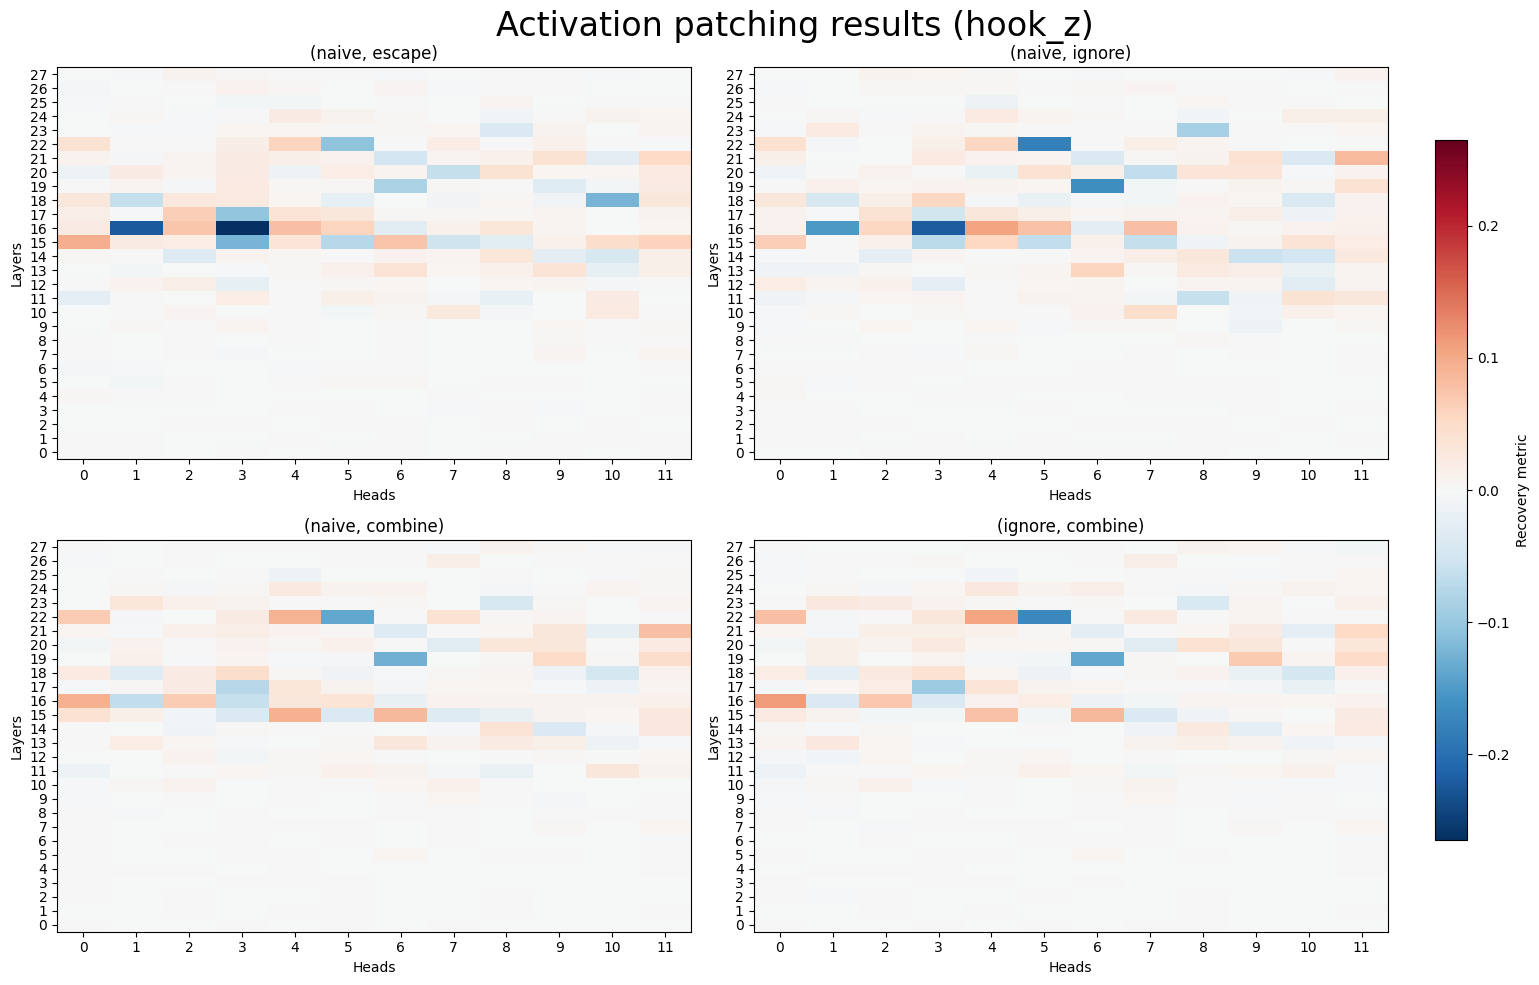

In [31]:
plot_all_patching(patching_results_z, N=30)